<a href="https://www.kaggle.com/code/kaoutharhamdan/rag-architetures-week-4?scriptVersionId=318711904" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Week 4 : RAG Architectures

## 1. Install dependencies

In [ ]:
!pip install -q sentence-transformers faiss-cpu transformers accelerate  

## 2. Load dataset

In [ ]:

import json
with open("/kaggle/input/datasets/kaoutharhamdan/datalaw/data.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)


documents = [item["text"] for item in raw_data]
doc_sources = [item["source"] for item in raw_data]
doc_ids = [item["id"] for item in raw_data]



In [ ]:
for i, (doc, src) in enumerate(zip(documents[:5], doc_sources[:5])):
    print(f"[{i+1}] Source: {src}")
    print(f"     Texte: {doc[:120]}...")
    print()


## LLM AND EMBEDDINGS

**Embeddings**

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
# explore more embedding models on : https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

**define the LLM**


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

model_name = "microsoft/Phi-4-mini-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

# Pipeline setup
# This wraps the model into a simple function: input → prompt, output → text
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

## LLM sans RAG

In [ ]:
def answer_question(question):
   
    prompt = f"<|user|>\n{question}\n\n<|assistant|>\n"
    
    response = generator(prompt, max_new_tokens=300, temperature=0.7)
    
    return response[0]['generated_text'].split("<|assistant|>")[-1].strip()

In [ ]:
question = "ما هي مدة التقادم المكسب للعقار؟"
answer = answer_question(question)
print(answer)

## RAG Classique, naïf 

In [ ]:
doc_embeddings = embedding_model.encode(documents)

In [ ]:
import faiss

dimension = doc_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(doc_embeddings))

print("FAISS index size:", index.ntotal)

**Retrieval function**

In [ ]:
def retrieve(query, k=3):
    # Convert query to vector
    query_vec = embedding_model.encode([query])
    # Search similar documents
    distances, indices = index.search(np.array(query_vec), k)
    # FAISS returns: closest vectors, their positions
    return [documents[i] for i in indices[0]]

In [ ]:
def rag_classic(query):
   
    retrieved_docs = retrieve(query, k=3)
    
  
    context = "\n\n".join(retrieved_docs)
    
    prompt = f"""<|system|>
أنت خبير في القانون العقاري المغربي. أجب على السؤال بناءً على السياق المقدم فقط.

<|user|>
السياق:
{context}

السؤال: {query}

<|assistant|>
"""
    
 
    response = generator(prompt, max_new_tokens=300, temperature=0.3)
    answer = response[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    return answer

In [ ]:
query = "ما هي مدة التقادم المكسب للعقار؟"
answer = rag_classic(query)
print(answer)

## RAG avec Re-ranking

In [ ]:
def rerank(query, docs):
    # Score documents by computing similarity between query and each doc
    query_vec = embedding_model.encode([query])
    doc_vecs = embedding_model.encode(docs)
    
    # Calculate cosine similarity scores
    scores = np.dot(doc_vecs, query_vec.T).flatten()
    
    # Sort documents by score (higher is better)
    scored_docs = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
    
    return scored_docs

In [ ]:
def rag_rerank(query):
    # 1. Retrieval (get initial k documents)
    retrieved_docs = retrieve(query, k=5)  # Get more docs for reranking
    
    # 2. Reranking (score and sort)
    reranked_docs = rerank(query, retrieved_docs)
    
    # 3. Take top 3 after reranking
    top_docs = [doc for doc, score in reranked_docs[:3]]
    
    # 4. Build prompt
    context = "\n\n".join(top_docs)
    
    prompt = f"""<|system|>
أنت خبير في القانون العقاري المغربي. أجب على السؤال بناءً على السياق المقدم فقط.

<|user|>
السياق:
{context}

السؤال: {query}

<|assistant|>
"""
    
    # 5. LLM generation
    response = generator(prompt, max_new_tokens=300, temperature=0.3)
    answer = response[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    return answer

In [ ]:
query = "ما هي مدة التقادم المكسب للعقار؟"
answer = rag_rerank(query)
print(answer)

## RAG Hybride

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\b\w+\b')
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

In [ ]:
def hybrid_retrieve(query, k=3):
    # 1. Dense retrieval (semantic)
    query_vec = embedding_model.encode([query])
    dense_distances, dense_indices = index.search(np.array(query_vec), k*2)
    dense_docs = [(documents[i], 1.0 - float(dense_distances[0][j])) for j, i in enumerate(dense_indices[0])]
    
    # 2. Sparse retrieval (keyword/TF-IDF)
    query_tfidf = tfidf_vectorizer.transform([query])
    sparse_scores = cosine_similarity(query_tfidf, tfidf_matrix).flatten()
    sparse_indices = sparse_scores.argsort()[-k*2:][::-1]
    sparse_docs = [(documents[i], float(sparse_scores[i])) for i in sparse_indices]
    
    # 3. Fusion (combine scores)
    all_docs = {}
    
    # Add dense results
    for doc, score in dense_docs:
        if doc not in all_docs:
            all_docs[doc] = 0
        all_docs[doc] += score
    
    # Add sparse results
    for doc, score in sparse_docs:
        if doc not in all_docs:
            all_docs[doc] = 0
        all_docs[doc] += score
    fused_results = sorted(all_docs.items(), key=lambda x: x[1], reverse=True)[:k]
    
    return [doc for doc, score in fused_results]

In [ ]:
def rag_hybrid(query):

    retrieved_docs = hybrid_retrieve(query, k=3)
    
    context = "\n\n".join(retrieved_docs)
    
    prompt = f"""<|system|>
أنت خبير في القانون العقاري المغربي. أجب على السؤال بناءً على السياق المقدم فقط.

<|user|>
السياق:
{context}

السؤال: {query}

<|assistant|>
"""
 
    response = generator(prompt, max_new_tokens=300, temperature=0.3)
    answer = response[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    return answer

In [ ]:
query = "ما هي مدة التقادم المكسب للعقار؟"
answer = rag_hybrid(query)
print(answer)

## Multi-hop RAG

In [ ]:
def multi_hop_rag(query):
    
    initial_docs = retrieve(query, k=2)
    initial_context = "\n\n".join(initial_docs)
    
    reformulation_prompt = f"""<|system|>
أنت مساعد قانوني. بناءً على المعلومات الأولى، قم بصياغة سؤال ثانٍ أكثر تحديداً للحصول على معلومات إضافية مطلوبة.

<|user|>
السؤال الأصلي: {query}

المعلومات المسترجعة:
{initial_context}

بناءً على هذه المعلومات، ماهو السؤال الثانوي الذي يجب طرحه للحصول على تفاصيل إضافية ضرورية للإجابة على السؤال الأصلي؟

<|assistant|>
"""
    
    reformulation_response = generator(reformulation_prompt, max_new_tokens=150, temperature=0.5)
    secondary_query = reformulation_response[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    # Étape 3: Second retrieval
    secondary_docs = retrieve(secondary_query, k=2)
    secondary_context = "\n\n".join(secondary_docs)
    
    # Étape 4: Final answer with all information
    final_prompt = f"""<|system|>
أنت خبير في القانون العقاري المغربي. أجب على السؤال الأصلي باستخدام جميع المعلومات المتاحة.

<|user|>
السؤال الأصلي: {query}

المعلومات من المرحلة الأولى:
{initial_context}

المعلومات من المرحلة الثانية:
{secondary_context}

الرجاء تقديم إجابة شاملة وكاملة.

<|assistant|>
"""
    
    final_response = generator(final_prompt, max_new_tokens=400, temperature=0.3)
    answer = final_response[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    return answer

In [ ]:
query = "ما هي مدة التقادم المكسب للعقار ومتى ينقطع؟"
answer = multi_hop_rag(query)
print(answer)

## Graph RAG

In [ ]:
def graph_rag(query):
   
    entity_prompt = f"""<|system|>
Extrais les entités juridiques importantes de cette question (ex: droits réels, prescription, propriété, etc.)

<|user|>
Question: {query}

<|assistant|>
"""
    entity_response = generator(entity_prompt, max_new_tokens=100, temperature=0.3)
    entities = entity_response[0]['generated_text'].split("<|assistant|>")[-1].strip()

    related_docs = retrieve(entities, k=4)
    

    relation_prompt = f"""<|system|>
Analyse les relations entre les entités juridiques trouvées dans les documents.

<|user|>
Entités: {entities}

Documents:
{"\n".join(related_docs[:2])}

Quelles sont les relations importantes entre ces concepts juridiques?

<|assistant|>
"""
    relation_response = generator(relation_prompt, max_new_tokens=200, temperature=0.3)
    relations = relation_response[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    final_prompt = f"""<|system|>
Expert en droit immobilier marocain. Réponds à la question en utilisant les entités et relations identifiées.

<|user|>
Question: {query}

Entités clés: {entities}

Relations juridiques: {relations}

Documents de référence:
{"\n\n".join(related_docs[:3])}

Réponse:

<|assistant|>
"""
    
    final_response = generator(final_prompt, max_new_tokens=400, temperature=0.3)
    answer = final_response[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    return answer

In [ ]:
query = "ما هي مدة التقادم المكسب للعقار ؟"
answer = graph_rag(query)
print(answer)

In [ ]:
def agentic_rag(query, max_iterations=3):
    # Initialize
    accumulated_context = []
    iteration = 0
    
    # Étape 1: Decision - retrieval or not
    decision_prompt = f"""<|system|>
Décide si tu as besoin de chercher des informations juridiques pour répondre à cette question.
Réponds par "RETRIEVAL" si tu as besoin de documents, ou "DIRECT" si tu peux répondre directement.

<|user|>
Question: {query}

<|assistant|>
"""
    
    decision = generator(decision_prompt, max_new_tokens=20, temperature=0.01)
    need_retrieval = "RETRIEVAL" in decision[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    # Étape 2: Reasoning loop
    while need_retrieval and iteration < max_iterations:
        # Search for relevant information
        if iteration == 0:
            docs = retrieve(query, k=2)
        else:
            # Reformulate query based on missing info
            reformulate_prompt = f"""<|system|>
Formule une nouvelle requête de recherche pour trouver les informations manquantes.

<|user|>
Question originale: {query}
Informations déjà trouvées: {''.join(accumulated_context)}
Qu'est-ce qui manque encore?

<|assistant|>
"""
            new_query = generator(reformulate_prompt, max_new_tokens=20, temperature=0)
            new_query_text = new_query[0]['generated_text'].split("<|assistant|>")[-1].strip()
            docs = retrieve(new_query_text, k=2)
        
        accumulated_context.extend(docs)
        iteration += 1
        
        # Evaluate if we have enough information
        evaluate_prompt = f"""<|system|>
As-tu assez d'informations pour répondre complètement à la question?
Réponds par "SUFFISANT" ou "INSUFFISANT".

<|user|>
Question: {query}
Informations collectées: {''.join(accumulated_context)}

<|assistant|>
"""
        evaluation = generator(evaluate_prompt, max_new_tokens=50, temperature=0)
        need_retrieval = "INSUFFISANT" in evaluation[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    # Étape 3: Final answer
    final_prompt = f"""<|system|>
Expert en droit immobilier marocain. Réponds à la question en utilisant toutes les informations collectées.

<|user|>
Question: {query}

Informations disponibles:
{''.join(accumulated_context)}

Réponse finale:

<|assistant|>
"""
    
    final_response = generator(final_prompt, max_new_tokens=500, temperature=0.3)
    answer = final_response[0]['generated_text'].split("<|assistant|>")[-1].strip()
    
    return answer

In [ ]:
query = "ما هي مدة التقادم المكسب للعقار ؟"
answer = agentic_rag(query)
print(answer)

## Résultats : Comparaison des architectures

In [ ]:
queries = [
    "ما هي مدة التقادم المكسب للحصول على ملكية عقار؟",
    "ما هي مدة الكراء الطويل حسب القانون المغربي؟",
    "متى ينقطع التقادم المكسب؟"
]



In [ ]:
import pandas as pd

# 1. Initialize Results Storage
# This will store the answers for each method per question
results_data = []

def evaluate_all_methods(queries):
    for i, query in enumerate(queries, 1):
        # Progress indicator
        print(f"Processing Question {i}/{len(queries)}...", end="\r")
        
        # We create a dictionary for this specific question
        row = {"Question": f"Q{i}"}
        
        # Map of method names to your RAG functions
        methods = [
            ("baseline", lambda q: answer_question(q)),
            ("rag_classic", lambda q: rag_classic(q)),
            ("rag_rerank", lambda q: rag_rerank(q)),
            ("rag_hybrid", lambda q: rag_hybrid(q)),
            ("multi_hop", lambda q: multi_hop_rag(q)),
            ("graph_rag", lambda q: graph_rag(q)),
            ("agentic_rag", lambda q: agentic_rag(q)),
        ]

        for key, func in methods:
            try:
                # Execute function and store the result
                answer = func(query)
                

                if isinstance(answer, tuple):
                    row[key] = answer[0]
                else:
                    row[key] = answer
            except Exception as e:
                row[key] = f"Error: {e}"
        
        results_data.append(row)

# 2. Run the evaluation
evaluate_all_methods(queries)
print("\nEvaluation complete.")

df_results = pd.DataFrame(results_data)
df_results.set_index("Question", inplace=True)


pd.set_option('display.max_colwidth', 50)

print("\n" + "="*100)
print("FINAL RESULTS TABLE")
print("="*100)
print(df_results)
print("="*100)

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Multilingual model to handle Arabic legal text
similarity_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

def compute_cosine_similarity(generated_answer, reference_answer):
    if not generated_answer or "Error" in generated_answer:
        return 0.0
    
    embeddings1 = similarity_model.encode(generated_answer, convert_to_tensor=True)
    embeddings2 = similarity_model.encode(reference_answer, convert_to_tensor=True)
    
    cosine_score = util.pytorch_cos_sim(embeddings1, embeddings2)
    return round(float(cosine_score), 4)

In [ ]:
import re

def judge_legal_accuracy(query, generated_answer):
    # Standardize input
    gen_ans_str = str(generated_answer)
    if not gen_ans_str or "Error" in gen_ans_str or len(gen_ans_str) < 5:
        return 0.0

    judgement_prompt = f"""<|system|>
You are a Moroccan Real Estate Law expert. Rate the answer from 0 to 10 based on legal accuracy.
Respond with ONLY the number.

<|user|>
Question: {query}
Answer: {gen_ans_str}

Score (0-10):
<|assistant|>"""
    
    try:
        # Use do_sample=False for consistency
        response = generator(judgement_prompt, max_new_tokens=10, do_sample=False)
        raw_text = response[0]['generated_text'].split("<|assistant|>")[-1].strip()
        
        # 1. Try to find the first number in the string (handles "9", "9/10", or "9.5")
        match = re.search(r"(\d+\.?\d*)", raw_text)
        if match:
            score = float(match.group(1))
            
            # 2. Normalize score to be between 0 and 1
            if score > 10: score = score / 100 # Handle 0-100 scales if LLM hallucinates them
            final_score = min(1.0, max(0.0, score / 10.0))
            return final_score
            
        return 0.0
    except Exception as e:
        # This will tell you if there is a code error (like a library missing)
        print(f"Extraction Error: {e}") 
        return 0.0

In [ ]:
golden_references = [
    "حسب المادة 23 من مدونة الحقوق العينية، مدة التقادم المكسب هي عشر سنوات إذا كان الحائز حسن النية ويتوفر على سند، أو ثلاثين سنة إذا لم يكن الأمر كذلك (الحيازة الطويلة).",
    "وفقاً للمادة 60 من القانون رقم 39-08، تتراوح مدة الكراء الطويل بين ثمانية عشر (18) عاما وتسعة وتسعين (99) عاما كحد أقصى.",
    "طبقاً للمادة 39 من مدونة الحقوق العينية، ينقطع التقادم باعتراف الحائز بحق المالك، أو بمطالبة قضائية، أو بأي إجراء من إجراءات التنفيذ الجبري. كما ينقطع طبيعياً بفقدان الحيازة (قرار محكمة النقض رقم 2003)."
]

# Dictionary to store final scores
performance_report = []

for method in df_results.columns:
    method_cosine = []
    method_judge = []
    
    for i, query in enumerate(queries):
        generated_ans = df_results.loc[f"Q{i+1}", method]
        ref_ans = golden_references[i]
        
        # Run Metrics
        method_cosine.append(compute_cosine_similarity(generated_ans, ref_ans))
        method_judge.append(judge_legal_accuracy(query, generated_ans))
    
    performance_report.append({
        "Method": method,
        "Avg Cosine Sim": sum(method_cosine) / len(method_cosine),
        "Avg LLM Judge": sum(method_judge) / len(method_judge)
    })

# Display Final Comparison Table
performance_df = pd.DataFrame(performance_report).set_index("Method")
print("\n" + "="*60)
print("RAG PERFORMANCE METRICS SUMMARY")
print("="*60)
print(performance_df)

# Architecture Performance Analysis

## 1. Most Performant Architecture

**Winner:** `agentic_rag`

**Justification:**  
Although `rag_hybrid` has a higher cosine similarity ($0.62$), Agentic RAG achieves the highest LLM Judge score ($0.90$). This means it is the most capable of reasoning over legal texts to provide accurate, validated answers—surpassing simple keyword matching.

## 2. Most Robust Architecture

**Winner:** `rag_hybrid`

**Justification:**  
Robustness is measured by the ability to consistently retrieve relevant content. With an Avg Cosine Sim of $0.628$ (the highest in the table), this method ensures the best semantic alignment between the Arabic question and stored legal articles. It is less sensitive to phrasing variations than classic RAG.

## 3. Most Suitable Architecture for the Project

**Candidates:** `graph_rag` or `agentic_rag`

**Analysis:**  
For a legal project (where articles are interconnected, e.g., the relationship between possession and prescription interruption), both Graph RAG ($0.86$ Judge) and Agentic RAG ($0.90$) excel.

**Verdict:**  
- Choose **Agentic RAG** if you need pure legal precision.  
- Choose **Graph RAG** if you want to understand relationships between different legal texts.

## 4. Architecture That Produces the Most Hallucinations

**Winner (loser):** `rag_classic` (or `rag_rerank`/`multi_hop` in this context)

**Justification:**  
`rag_classic` shows an Avg LLM Judge of $0.0$, indicating that it either fails to retrieve information or invents non-compliant answers unsupported by the provided documents.

> **Note on Baseline:** The baseline ($0.63$ Judge) also hallucinates because it responds using its own knowledge without citing your specific documents—this is dangerous in a strict legal context.

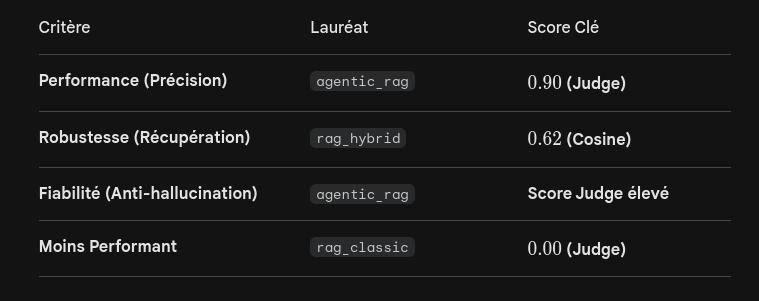